In [1]:
from ms2maccs import MS2MACCS
from matchms.importing import load_from_mgf
from rdkit.Chem import MolFromSmiles
from rdkit.Chem import MACCSkeys
import numpy as np

In [2]:
predictor = MS2MACCS(
    bit_map_p_mode_path="fp_bit_map_H_p_mode.pkl",
    bit_map_n_mode_path="fp_bit_map_H_n_mode.pkl",
    model_path="model.pt",
    use_formula_attn=False,
    batch_size=32,
    device="cpu"
)

C:\Users\dietr004\AppData\Local\anaconda3\envs\nts\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [11]:
spectra = list(load_from_mgf("test_specs_H.mgf"))

In [12]:
preds = predictor.predict("test_specs_H.mgf")

Loaded 1484 spectra from test_specs_H.mgf


Preprocessing test_specs_H.mgf: 100%|█████████████████████████████████████████████| 1484/1484 [00:06<00:00, 231.13it/s]


  → 1484 valid  |  0 skipped


Predicting: 100%|██████████████████████████████████████████████████████████████████████| 47/47 [00:10<00:00,  4.38it/s]


In [19]:
tanimoto_scores = []
for i in range(len(spectra)):
    preds_boolean = preds[i] > 0.5
    preds_boolean = preds_boolean.numpy()

    smiles = spectra[i].get("smiles")
    mol = MolFromSmiles(smiles)
    maccs = np.array(MACCSkeys.GenMACCSKeys(mol))
    maccs_boolean = maccs > 0.5

    tanimoto = sum(maccs_boolean & preds_boolean)/sum(maccs_boolean | preds_boolean)
    tanimoto_scores.append(tanimoto)

In [20]:
np.mean(tanimoto_scores), np.median(tanimoto_scores)

(np.float64(0.577919005929195), np.float64(0.5806451612903226))

In [21]:
i = 186
preds_boolean = preds[i] > 0.5
preds_boolean = preds_boolean.numpy()

In [22]:
smiles = spectra[i].get("smiles")
mol = MolFromSmiles(smiles)
maccs = np.array(MACCSkeys.GenMACCSKeys(mol))
maccs_boolean = maccs > 0.5

In [23]:
sum(maccs_boolean & preds_boolean)/sum(maccs_boolean | preds_boolean)

np.float64(0.5333333333333333)

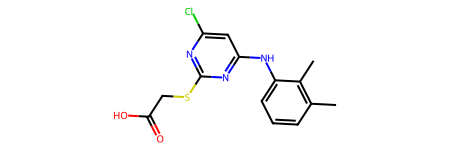

In [24]:
mol